🛰️ MintPy Daily-Use Code Repository — OpenSARLab Edition
Kernel Requirement: Every cell in this notebook must use the osl_mintpy kernel.
Check and switch it in the top-right corner of your Jupyter interface.
The default Python 3 kernel will fail with ModuleNotFoundError.

Universal Path Setup — Run This First in Every Session

**What it does:** Declares a master `DATA_DIR` variable pointing to your MintPy output folder.  
All 18 snippets below depend on this variable. Run this cell first, every time.

In [1]:
import os

# Change this to your actual MintPy geo-coded output folder in OpenSARLab.
# Typical OpenSARLab paths begin with /home/jovyan/
DATA_DIR = "/home/jovyan/dhaka/HyP3_downloads/MintPy"

# Verify the path actually exists before proceeding
if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"DATA_DIR not found: {DATA_DIR}\nCheck your path and try again.")

print(f"✅ Data directory confirmed: {DATA_DIR}")

✅ Data directory confirmed: /home/jovyan/dhaka/HyP3_downloads/MintPy


14 — Generate a Velocity Distribution Histogram

**What it does:** Plots a histogram of all pixel velocities across your study area.  
**When to use:** Run this early to understand the overall deformation regime.
A bell curve centered near zero means the area is mostly stable.
A left-skewed distribution indicates widespread subsidence.

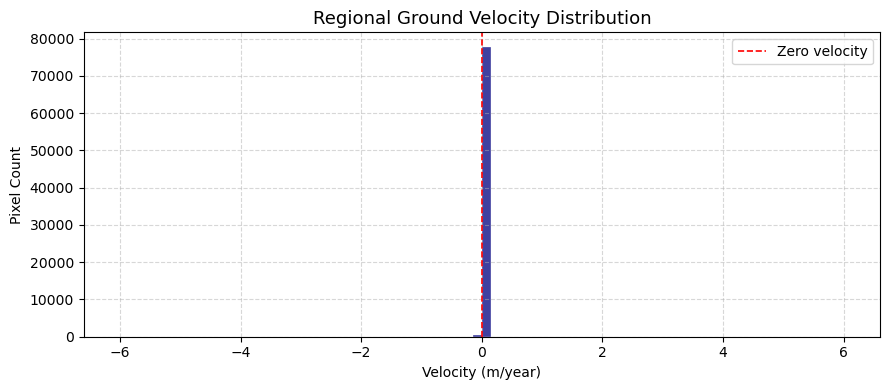

Mean velocity  : 0.001 m/year
Median velocity: 0.000 m/year
Std deviation  : 0.004 m/year


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mintpy.utils import readfile

file_path = f"{DATA_DIR}/velocity.h5"
velocity, meta = readfile.read(file_path)

unit = meta.get('UNIT', 'cm/year')
flat = velocity.flatten()
flat = flat[~np.isnan(flat)]   # exclude NaN pixels from statistics

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(flat, bins=80, range=(-6, 6), color='navy', alpha=0.75, edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero velocity')
ax.set_title("Regional Ground Velocity Distribution", fontsize=13)
ax.set_xlabel(f"Velocity ({unit})")
ax.set_ylabel("Pixel Count")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Mean velocity  : {flat.mean():.3f} {unit}")
print(f"Median velocity: {np.median(flat):.3f} {unit}")
print(f"Std deviation  : {flat.std():.3f} {unit}")